structure du projet 
4) Installer et importer seaborn, matplotlib, pandas, numpy

In [5]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


5) Importer mesures_capteurs.csv dans le dataframe df

In [7]:
df = pd.read_csv("../data/mesures_capteurs.csv")

6) Vérifier le contenu du dataframe df

In [8]:
print(df)

    id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0       M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1       M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2       M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3       M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4       M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   
..        ...                  ...        ...      ...          ...       ...   
600     M0072  2026-01-07 23:00:00       C012     B004        23.67     60.28   
601     M0107  2026-01-09 10:00:00       C011     B004        24.34     61.42   
602     M0271  2026-01-16 06:00:00       C007     B003        23.73     63.49   
603     M0436  2026-01-23 03:00:00       C004     B002        24.83     79.77   
604     M0103  2026-01-09 06:00:00       C007     B003        17.02     52.04   

     pression  consommation

Partie 1 – Distribution d'une variable avec histplot()
1) Afficher la distribution des températures

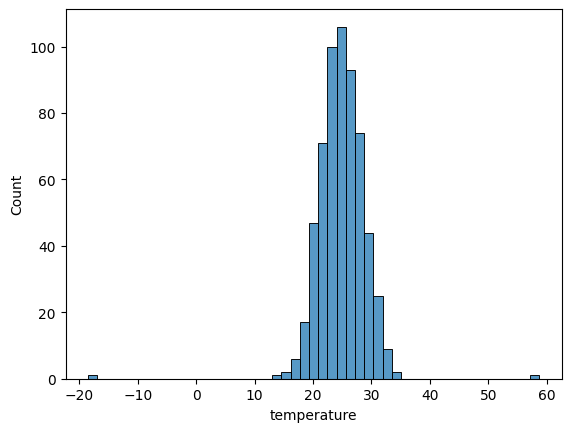

In [9]:
sns.histplot(data=df, x="temperature")

plt.show()

2) Autour de quelle valeur les températures sont concentrées ?

les temperatures sont plus concentrées autour de 20 et 30 

3) La distribution semble-t-elle symétrique ?

oui la distribution semble symétrique

4) Existe-t-il des valeurs extrêmes ?

oui il existe des valeurs extremes

5) Modifier le nombre de classes

<Axes: xlabel='temperature', ylabel='Count'>

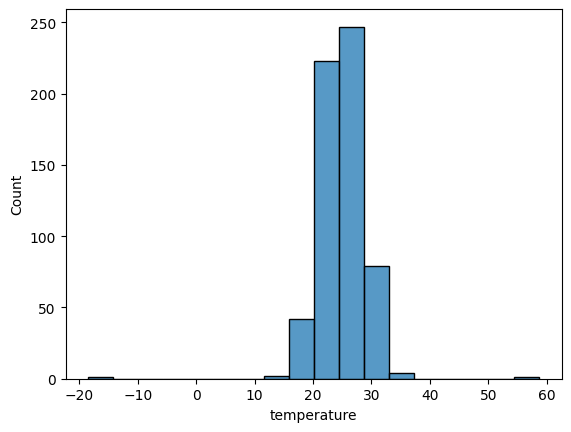

In [12]:
sns.histplot(data=df, x="temperature", bins=18)

6) Afficher la distribution des températures par bâtiment

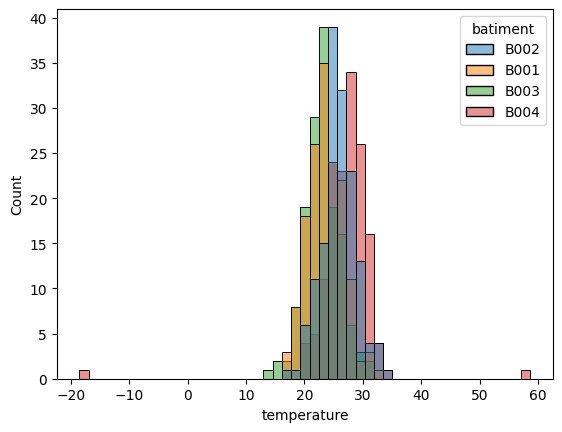

In [ ]:
sns.histplot(
    data=df,
    x="temperature",
    hue="batiment"
)

plt.show()

Partie 2 – Distribution d'une variable avec kdeplot()
1) Afficher la distribution des températures

<Axes: xlabel='temperature', ylabel='Density'>

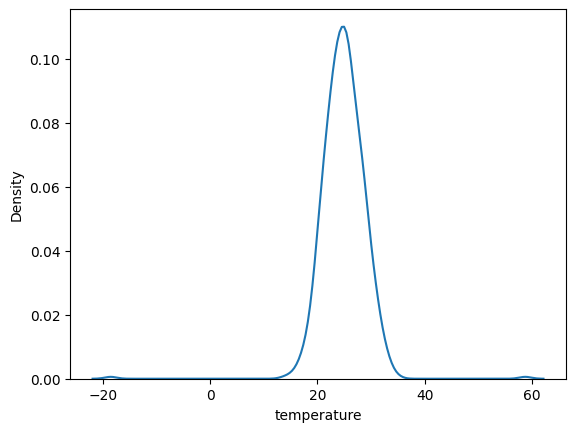

In [19]:
sns.kdeplot(data=df, x="temperature")

2) Afficher la distribution des températures par bâtiment

<Axes: xlabel='temperature', ylabel='Density'>

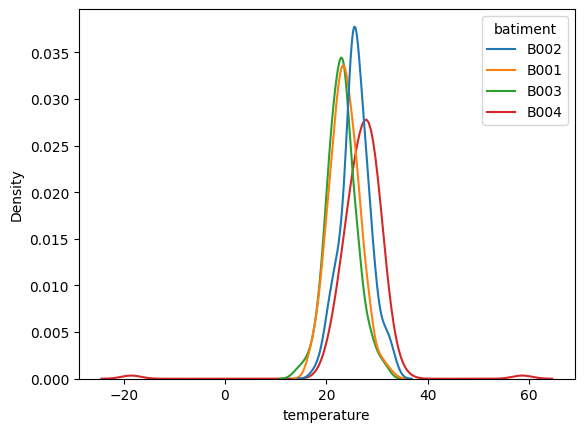

In [20]:
sns.kdeplot(data=df, x="temperature", hue="batiment")

Partie 3 – Distribution d'une variable avec boxplot()
1) Afficher la distribution des températures

Text(0, 0.5, 'temperature')

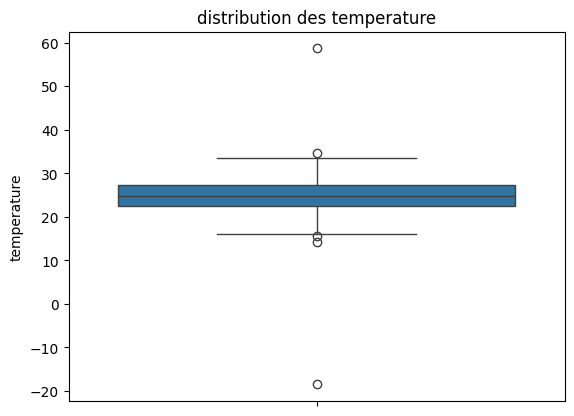

In [31]:
sns.boxplot(y=df["temperature"])
plt.title("distribution des temperature")
plt.ylabel("temperature")


2) Afficher la distribution des températures par bâtiment

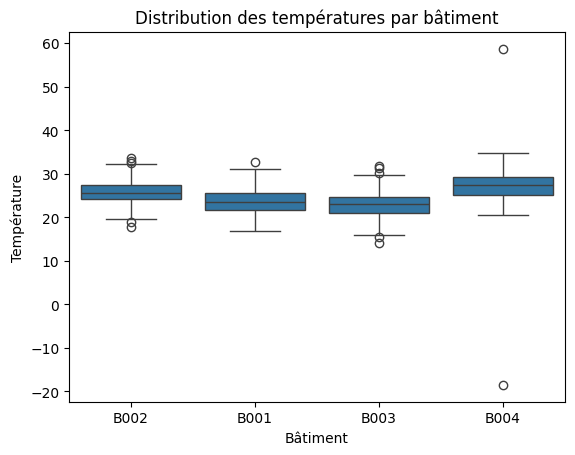

In [34]:
sns.boxplot(x="batiment", y="temperature", data=df)

plt.title("Distribution des températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température")
plt.show()

3) Pour chaque bâtiment,
a) quelle est la médiane ?

pour le batiment 1 la mediane est : 25
pour le batiment 2 la mediane est : 23
pour le batiment 3 la mediane est : 22
pour le batiment 4 la mediane est : 28


b) quelle est la dispersion ?

In [35]:
df.groupby("batiment")["temperature"].agg(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)

batiment
B001    4.0600
B002    3.2625
B003    3.5125
B004    4.1075
Name: temperature, dtype: float64

c) les valeurs extrêmes

les valeurs extremes pour chaque batiment:
pour le batiment 1 : environ 18 °C, 19 °C, 32 °C, 33 °C
pour le batiment 2 : environ 33 °C  
pour le batiment 3 : environ 14 °C, 15 °C, 30 °C, 31 °C
pour le batiment 4 : environ -19 °C et 58 °C   



Partie 4 – Distribution d'une variable avec violinplot()
1) Afficher la distribution des températures

<Axes: xlabel='temperature'>

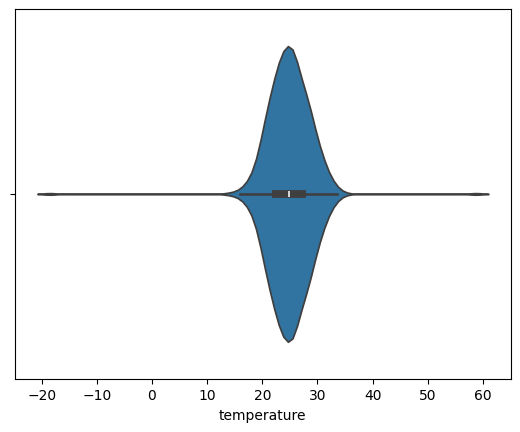

In [36]:
sns.violinplot(data=df, x="temperature")

2) Afficher la distribution des températures par bâtiment

<Axes: xlabel='temperature', ylabel='batiment'>

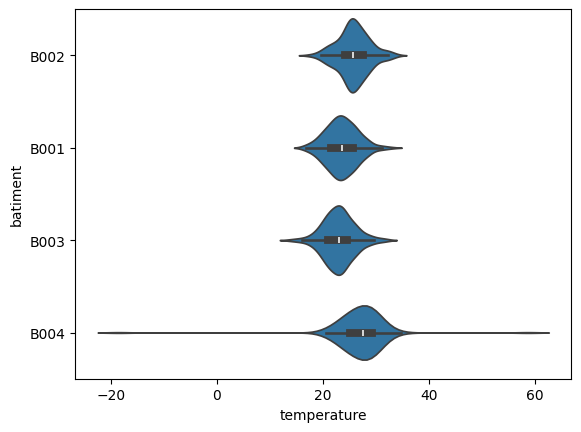

In [38]:
sns.violinplot(data=df, x="temperature", y="batiment")


3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box
plot ?

Le boxplot permet surtout de voir :

la médiane les quartiles, la dispersion,
les valeurs extrêmes et les éventuels outliers.

Le violin plot contient ces informations mais montre en plus la forme de la distribution, grâce à la largeur du "violon".

Partie 5 – Comptage des catégories avec countplot()
1) Afficher le nombre de mesures par état

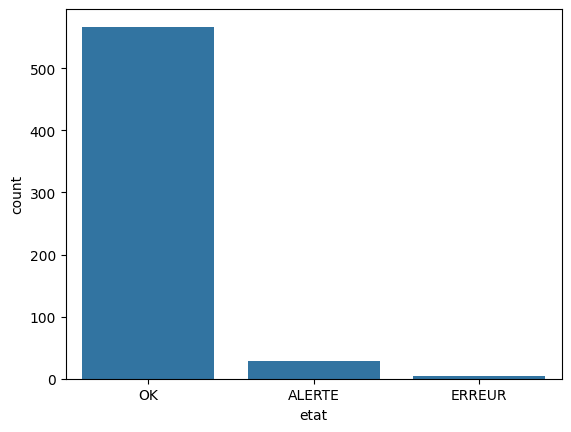

In [39]:
sns.countplot(data=df, x="etat")
plt.show()